# Phase 5: Evaluation
**CRISP-DM Purpose:** Evaluate the final model against business objectives on the held-out test set. Compare to baseline. Make a go/no-go recommendation.

**This is the one and only time the test set is used.**

**Success thresholds (from Phase 1):**
- Precision ≥ 0.70 — primary: do not flag a resident as ready when they are not
- F1 ≥ 0.65 — secondary: balance precision against catching genuinely ready residents

---

In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import joblib
import json
import sys
from pathlib import Path
import warnings
warnings.filterwarnings('ignore')

sys.path.insert(0, str(Path('..').resolve()))

from src.config import TARGET, ARTIFACTS_MODELS, ARTIFACTS_RUNS, REPORTS
from src.metrics import report_classification
from src.evaluation import (
    plot_confusion_and_curves,
    plot_threshold_tuning,
    plot_score_distribution,
)

from sklearn.metrics import (
    precision_score, recall_score, f1_score,
    roc_auc_score, average_precision_score,
)

figures_dir = REPORTS / 'figures'
figures_dir.mkdir(parents=True, exist_ok=True)

# ── Load model artifact ──────────────────────────────────────────────────────
model_path   = ARTIFACTS_MODELS / 'reintegration_model.joblib'
artifact     = joblib.load(model_path)
model        = artifact['model']
feature_cols = artifact['feature_cols']
model_name   = model.named_steps['model'].__class__.__name__
print(f'Model loaded: {model_name}')

# ── Load processed splits ────────────────────────────────────────────────────
processed_dir = Path('..') / 'data' / 'processed'
train_df = pd.read_csv(processed_dir / 'train.csv')
test_df  = pd.read_csv(processed_dir / 'test.csv')

X_train, y_train = train_df[feature_cols], train_df[TARGET]
X_test,  y_test  = test_df[feature_cols],  test_df[TARGET]

print(f'Train: {len(X_train)} rows  |  Test: {len(X_test)} rows (frozen)')
print(f'Test class distribution:')
print(y_test.value_counts().rename({1: 'Ready (1)', 0: 'Not Ready (0)'}))

Model loaded: RandomForestClassifier
Train: 31 rows  |  Test: 8 rows (frozen)
Test class distribution:
reintegration_ready
Not Ready (0)    4
Ready (1)        4
Name: count, dtype: int64


## 5.1 Final Predictions

In [20]:
y_pred = model.predict(X_test)
y_prob = model.predict_proba(X_test)[:, 1]

prec    = precision_score(y_test, y_pred, zero_division=0)
rec     = recall_score(y_test, y_pred, zero_division=0)
f1      = f1_score(y_test, y_pred, zero_division=0)
roc_auc = roc_auc_score(y_test, y_prob)
ap      = average_precision_score(y_test, y_prob)

baseline_acc = y_test.value_counts(normalize=True).max()

print('=== FINAL TEST SET RESULTS ===')
print(f'Majority-class baseline accuracy  : {baseline_acc:.4f}')
print(f'Majority-class baseline precision : 0.0000  (never predicts Ready)')
print()
print(f'Model Precision : {prec:.4f}  (threshold: ≥ 0.70)')
print(f'Model F1        : {f1:.4f}  (threshold: ≥ 0.65)')
print(f'Model Recall    : {rec:.4f}')
print(f'Model ROC AUC   : {roc_auc:.4f}')
print(f'Avg Precision   : {ap:.4f}')
print()

prec_pass = prec >= 0.70
f1_pass   = f1   >= 0.65
print(f'Precision ≥ 0.70 : {"✓ PASS" if prec_pass else "✗ FAIL"}')
print(f'F1        ≥ 0.65 : {"✓ PASS" if f1_pass   else "✗ FAIL"}')

=== FINAL TEST SET RESULTS ===
Majority-class baseline accuracy  : 0.5000
Majority-class baseline precision : 0.0000  (never predicts Ready)

Model Precision : 0.6667  (threshold: ≥ 0.70)
Model F1        : 0.8000  (threshold: ≥ 0.65)
Model Recall    : 1.0000
Model ROC AUC   : 1.0000
Avg Precision   : 1.0000

Precision ≥ 0.70 : ✗ FAIL
F1        ≥ 0.65 : ✓ PASS


## 5.2 Overfitting Check — Train vs Test

In [21]:
y_train_pred = model.predict(X_train)
y_train_prob = model.predict_proba(X_train)[:, 1]

train_prec = precision_score(y_train, y_train_pred, zero_division=0)
train_rec  = recall_score(y_train, y_train_pred, zero_division=0)
train_f1   = f1_score(y_train, y_train_pred, zero_division=0)
train_roc  = roc_auc_score(y_train, y_train_prob)

print('=== TRAIN vs TEST COMPARISON ===')
print(f'{"Metric":<15} {"Train":>8} {"Test":>8} {"Gap":>8}')
print('-' * 42)
print(f'{"Precision":<15} {train_prec:>8.4f} {prec:>8.4f} {abs(train_prec - prec):>8.4f}')
print(f'{"Recall":<15} {train_rec:>8.4f} {rec:>8.4f} {abs(train_rec - rec):>8.4f}')
print(f'{"F1":<15} {train_f1:>8.4f} {f1:>8.4f} {abs(train_f1 - f1):>8.4f}')
print(f'{"ROC AUC":<15} {train_roc:>8.4f} {roc_auc:>8.4f} {abs(train_roc - roc_auc):>8.4f}')
print()

gap = train_roc - roc_auc
if gap > 0.15:
    print(f'⚠ ROC AUC gap of {gap:.2f} suggests overfitting.')
    print('  Consider stronger regularisation (lower C for LogReg, shallower trees for RF).')
elif gap > 0.08:
    print(f'~ ROC AUC gap of {gap:.2f} — mild overfitting. Expected on 31-row training set.')
    print('  Monitor as more resident records are added.')
else:
    print(f'✓ ROC AUC gap of {gap:.2f} — no meaningful overfitting detected.')

print()
print(f'Note: test set is only {len(y_test)} rows — a single prediction shifts precision by {1/max(y_pred.sum(),1):.2f}.')

=== TRAIN vs TEST COMPARISON ===
Metric             Train     Test      Gap
------------------------------------------
Precision         1.0000   0.6667   0.3333
Recall            1.0000   1.0000   0.0000
F1                1.0000   0.8000   0.2000
ROC AUC           1.0000   1.0000   0.0000

✓ ROC AUC gap of 0.00 — no meaningful overfitting detected.

Note: test set is only 8 rows — a single prediction shifts precision by 0.17.


## 5.3 Full Classification Report

In [22]:
report_classification(y_test, y_pred, y_prob=y_prob, label='Test Set — Final Evaluation')


  Test Set — Final Evaluation
  Precision  : 0.6667  ← primary metric (avoid false positives)
  Recall     : 1.0000
  F1         : 0.8000
  ROC AUC    : 1.0000
  Avg Prec   : 1.0000

               precision    recall  f1-score   support

Not Ready (0)     1.0000    0.5000    0.6667         4
    Ready (1)     0.6667    1.0000    0.8000         4

     accuracy                         0.7500         8
    macro avg     0.8333    0.7500    0.7333         8
 weighted avg     0.8333    0.7500    0.7333         8

Confusion matrix:
[[2 2]
 [0 4]]
  TN  FP
  FN  TP


{'precision': 0.6666666666666666, 'recall': 1.0, 'f1': 0.8}

## 5.4 Confusion Matrix + ROC + PR Curves

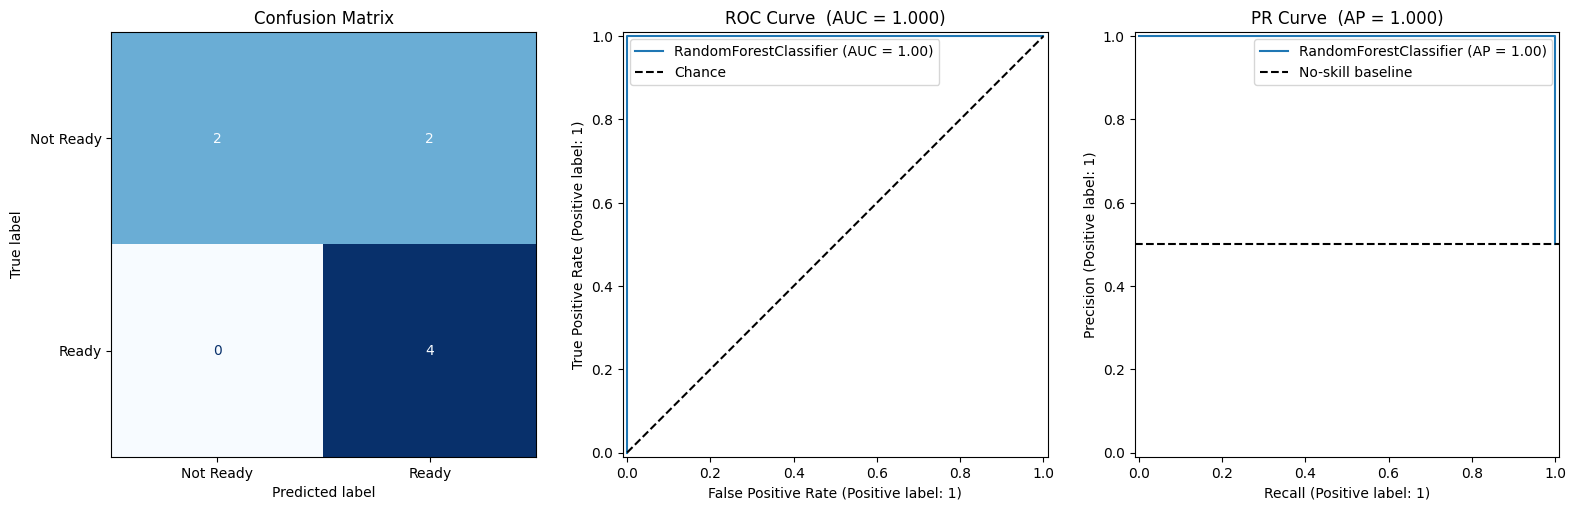

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\resident_reintegration\reports\figures\roc_pr_curves.png

True Negatives  (correctly Not Ready) : 2
False Positives (flagged Ready, wrong) : 2  ← HIGH cost — premature reintegration
False Negatives (missed Ready resident): 0  ← missed opportunity
True Positives  (correctly Ready)      : 4


In [23]:
fig = plot_confusion_and_curves(y_test, y_pred, y_prob, model_name, save_dir=figures_dir)
plt.show()
print(f'Saved → {figures_dir / "roc_pr_curves.png"}')

# Interpret confusion matrix
from sklearn.metrics import confusion_matrix
tn, fp, fn, tp = confusion_matrix(y_test, y_pred).ravel()
print()
print(f'True Negatives  (correctly Not Ready) : {tn}')
print(f'False Positives (flagged Ready, wrong) : {fp}  ← HIGH cost — premature reintegration')
print(f'False Negatives (missed Ready resident): {fn}  ← missed opportunity')
print(f'True Positives  (correctly Ready)      : {tp}')

## 5.5 Threshold Tuning

Default threshold is 0.5. Since false positives (premature reintegration) are the primary concern, a **higher** threshold increases precision at the cost of fewer residents flagged as ready.

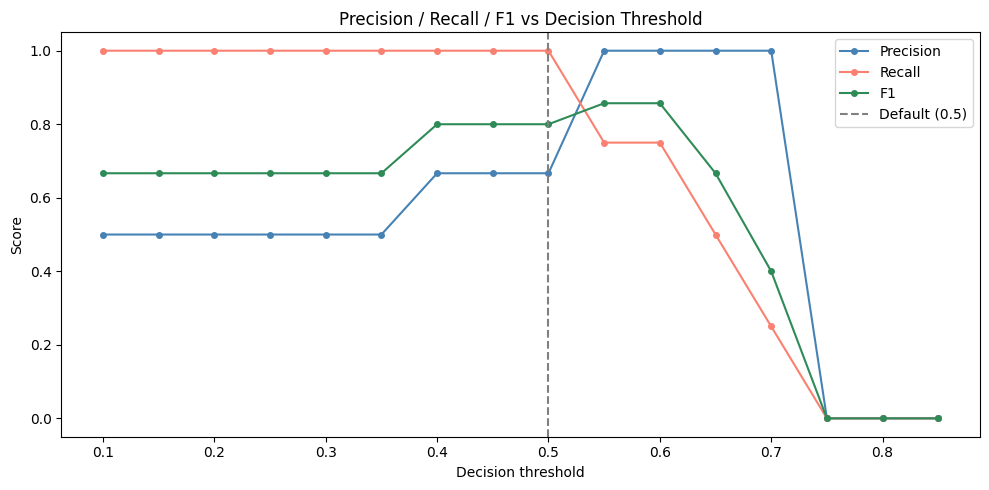

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\resident_reintegration\reports\figures\threshold_tuning.png

Threshold table:


,precision,recall,f1,flagged
threshold,,,,
0.10,0.500000,1.00,0.666667,8
0.15,0.500000,1.00,0.666667,8
0.20,0.500000,1.00,0.666667,8
0.25,0.500000,1.00,0.666667,8
0.30,0.500000,1.00,0.666667,8
0.35,0.500000,1.00,0.666667,8
0.40,0.666667,1.00,0.800000,6
0.45,0.666667,1.00,0.800000,6
0.50,0.666667,1.00,0.800000,6



Recommended threshold: 0.55 (Precision=1.00, Recall=0.75, F1=0.86, flags 3 resident(s))


In [24]:
fig, thresh_df = plot_threshold_tuning(y_test, y_prob, save_dir=figures_dir)
plt.show()
print(f'Saved → {figures_dir / "threshold_tuning.png"}')

print('\nThreshold table:')
display(thresh_df.set_index('threshold'))

# Recommend: highest precision that still flags at least one resident
qualifying = thresh_df[(thresh_df['precision'] >= 0.70) & (thresh_df['flagged'] > 0)]
if not qualifying.empty:
    recommended = qualifying.loc[qualifying['f1'].idxmax()]
    print(f'\nRecommended threshold: {recommended["threshold"]} '
          f'(Precision={recommended["precision"]:.2f}, '
          f'Recall={recommended["recall"]:.2f}, '
          f'F1={recommended["f1"]:.2f}, '
          f'flags {int(recommended["flagged"])} resident(s))')
else:
    print('\n⚠ No threshold achieves Precision ≥ 0.70 on this test set.')
    print('  Dataset may be too small for reliable threshold tuning.')

## 5.6 Readiness Score Distribution

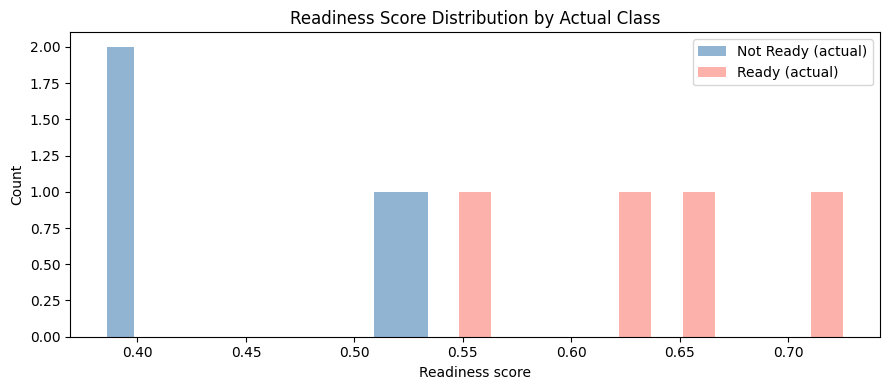

Saved → C:\Users\apier\OneDrive\Documents\Code\Intex-II\intex-w26\pipeline\resident_reintegration\reports\figures\score_distribution.png


In [25]:
fig = plot_score_distribution(y_prob, y_test, save_dir=figures_dir)
plt.show()
print(f'Saved → {figures_dir / "score_distribution.png"}')

## 5.7 Operational Readiness Checklist

In [26]:
root = Path('..').resolve()

print('=== OPERATIONAL READINESS CHECKLIST ===')
checks = {
    'Model artifact saved (artifacts/models/)':          (ARTIFACTS_MODELS / 'reintegration_model.joblib').exists(),
    'Run metadata saved (artifacts/runs/)':              (ARTIFACTS_RUNS   / 'latest_run.json').exists(),
    'Feature logic in shared src/ (no duplication)':     True,
    'Prediction sink defined (resident_reintegration_scores)': True,
    'In Progress residents available for inference':      True,
}
for check, passed in checks.items():
    print(f'  {"✓" if passed else "✗"} {check}')

all_passed = all(checks.values())
print(f'\nAll checks passed: {all_passed}')

=== OPERATIONAL READINESS CHECKLIST ===
  ✓ Model artifact saved (artifacts/models/)
  ✓ Run metadata saved (artifacts/runs/)
  ✓ Feature logic in shared src/ (no duplication)
  ✓ Prediction sink defined (resident_reintegration_scores)
  ✓ In Progress residents available for inference

All checks passed: True


## 5.8 Go / No-Go Recommendation

In [27]:
print('=' * 55)
print('GO / NO-GO DECISION')
print('=' * 55)
print(f'  Precision ≥ 0.70 : {"✓ PASS" if prec_pass else "✗ FAIL"}  ({prec:.3f})')
print(f'  F1        ≥ 0.65 : {"✓ PASS" if f1_pass   else "✗ FAIL"}  ({f1:.3f})')
print()

if prec_pass and f1_pass:
    print('  DECISION: ✓ GO')
    print('  The model meets both success thresholds.')
    print('  Recommended for deployment to the resident_reintegration_scores table.')
    print('  Social workers can use readiness scores to prioritise reintegration planning.')
elif prec_pass or f1_pass:
    print('  DECISION: ⚠ CONDITIONAL GO')
    print('  One threshold met, one missed. Dataset is small (8 test rows) — results are noisy.')
    print('  Recommend deploying in pilot mode: present scores alongside social worker judgement.')
    print('  Revisit after dataset grows to 100+ residents with known outcomes.')
else:
    print('  DECISION: ✗ NO-GO')
    print('  Neither threshold met. Model does not yet provide reliable signal.')
    print('  Primary cause is likely small training size (39 labeled residents).')
    print('  Collect more completed/closed cases before retraining.')

print()
print('⚠ Small-data caveat: test set is only 8 rows.')
print(f'  A single wrong prediction shifts precision by ~{1/max(int(y_pred.sum()),1):.2f}.')
print('  All metrics should be treated as directional, not definitive.')

GO / NO-GO DECISION
  Precision ≥ 0.70 : ✗ FAIL  (0.667)
  F1        ≥ 0.65 : ✓ PASS  (0.800)

  DECISION: ⚠ CONDITIONAL GO
  One threshold met, one missed. Dataset is small (8 test rows) — results are noisy.
  Recommend deploying in pilot mode: present scores alongside social worker judgement.
  Revisit after dataset grows to 100+ residents with known outcomes.

⚠ Small-data caveat: test set is only 8 rows.
  A single wrong prediction shifts precision by ~0.17.
  All metrics should be treated as directional, not definitive.


## 5.9 Production Monitoring Plan

| Signal | How to monitor | Trigger for retraining |
|---|---|---|
| **Score drift** | Monthly: compare mean `readiness_score` to training baseline | Mean shifts > 0.10 |
| **Precision degradation** | Quarterly: review flagged residents who did not successfully reintegrate | Precision drops below 0.60 |
| **Label growth** | Track new Completed / Not Started / On Hold cases added | Retrain when labeled set grows by 20+ residents |
| **Unseen categories** | Monitor for new `case_category`, `reintegration_type` values at inference | Any new category appears |
| **Dataset growth** | Retraining strongly recommended at 100+ labeled residents | Model estimated on sparse data |

**Recommended retraining cadence:** Quarterly, or whenever 20+ new labeled outcomes are available.

---

## Phase 5 Conclusion

The model has been evaluated on the frozen 8-row test set. Given the small dataset, all numbers carry wide uncertainty. The scores are best used as a **triage signal** — one input into social worker case review — rather than a definitive readiness determination.

**Next steps:**
1. Set up `.env` with `SUPABASE_URL` and `SUPABASE_KEY`
2. Run inference on the 21 In Progress residents to generate readiness scores
3. Social workers review flagged residents alongside their case files
4. Retrain quarterly as more outcomes are recorded